# Exploratory data analysis of the metadata files:

- **citing_metadata.csv** — citing cases (661 rows)
- **cited_metadata.csv** — cited cases (30,552 rows)
- **authority_metadata.csv** — matched authority citations (24,312 rows)
- **unmatched_metadata.csv** — unmatched citations (6,240 rows)
- **ids.csv** — cluster IDs (381 rows)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

DATA_DIR = "data/"

citing = pd.read_csv(f"{DATA_DIR}citing_metadata.csv")
cited = pd.read_csv(f"{DATA_DIR}cited_metadata.csv")
authority = pd.read_csv(f"{DATA_DIR}authority_metadata.csv")
unmatched = pd.read_csv(f"{DATA_DIR}unmatched_metadata.csv")
ids = pd.read_csv(f"{DATA_DIR}ids.csv", header=None, names=["cluster_id"])

print(f"citing:    {citing.shape}")
print(f"cited:     {cited.shape}")
print(f"authority: {authority.shape}")
print(f"unmatched: {unmatched.shape}")
print(f"ids:       {ids.shape}")

citing:    (661, 8)
cited:     (30551, 6)
authority: (24311, 5)
unmatched: (6240, 3)
ids:       (383, 1)


## 1. Citing Metadata Overview

In [2]:
citing.head()

,cluster_id,source,court,case_name,year,num_authorities,num_unmatched_citations,opinion_text_length
0,7163957,sampled,ca6,United States v. Oldham,2001,18,2,20960
1,2648327,sampled,ca6,United States v. Trent Shepard,2014,10,2,25370
2,1189968,sampled,ca6,United States v. Purcell,2008,54,16,92675
3,747632,sampled,ca6,In Re Perrigo Company,1997,108,34,163832
4,725244,sampled,ca6,United States v. Donald E. Hoy,1996,16,3,26570


In [3]:
citing.describe()

,cluster_id,year,num_authorities,num_unmatched_citations,opinion_text_length
count,6.610000e+02,661.000000,661.000000,661.000000,661.000000
mean,3.003140e+06,1997.508321,36.779123,9.440242,52708.809380
std,3.302803e+06,22.103174,44.552790,16.485480,68156.496497
min,1.520000e+02,1895.000000,1.000000,0.000000,608.000000
25%,4.690710e+05,1989.000000,11.000000,1.000000,15268.000000
50%,8.591590e+05,2002.000000,22.000000,4.000000,29955.000000
75%,4.707526e+06,2013.000000,47.000000,11.000000,64818.000000
max,1.080856e+07,2026.000000,379.000000,146.000000,656571.000000


In [4]:
print("Missing values:")
print(citing.isnull().sum())
print(f"\nUnique courts: {citing['court'].nunique()}")
print(f"Unique sources: {citing['source'].nunique()}")
print(f"Year range: {citing['year'].min()} - {citing['year'].max()}")

Missing values:
cluster_id                  0
source                      0
court                       0
case_name                  23
year                        0
num_authorities             0
num_unmatched_citations     0
opinion_text_length         0
dtype: int64

Unique courts: 13
Unique sources: 2
Year range: 1895 - 2026


### Distribution of courts and sources

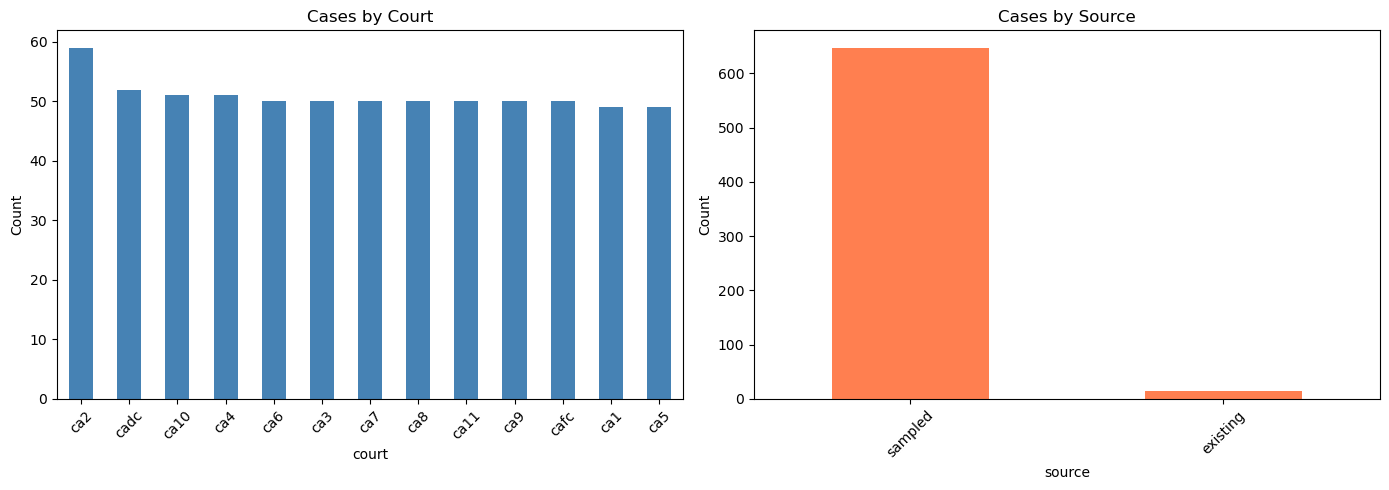

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

citing["court"].value_counts().plot.bar(ax=axes[0], color="steelblue")
axes[0].set_title("Cases by Court")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

citing["source"].value_counts().plot.bar(ax=axes[1], color="coral")
axes[1].set_title("Cases by Source")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Year distribution

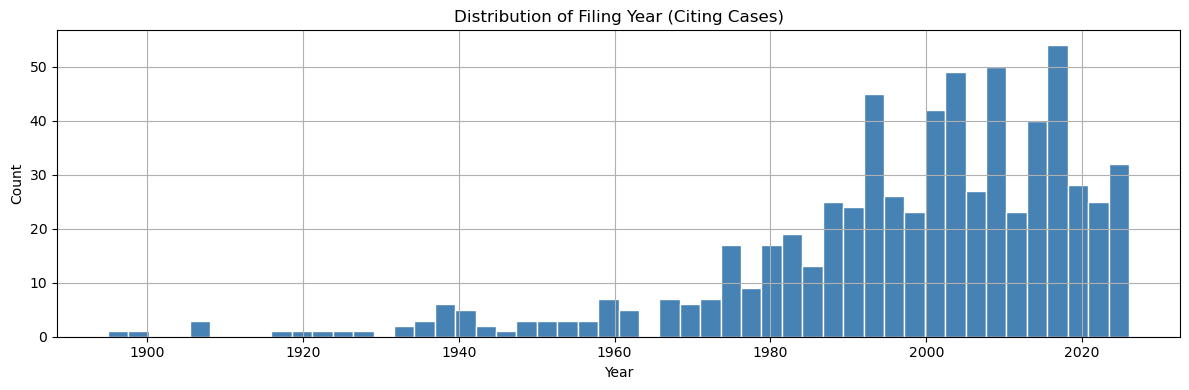

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))
citing["year"].hist(bins=50, ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Distribution of Filing Year (Citing Cases)")
ax.set_xlabel("Year")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

### Numeric feature distributions

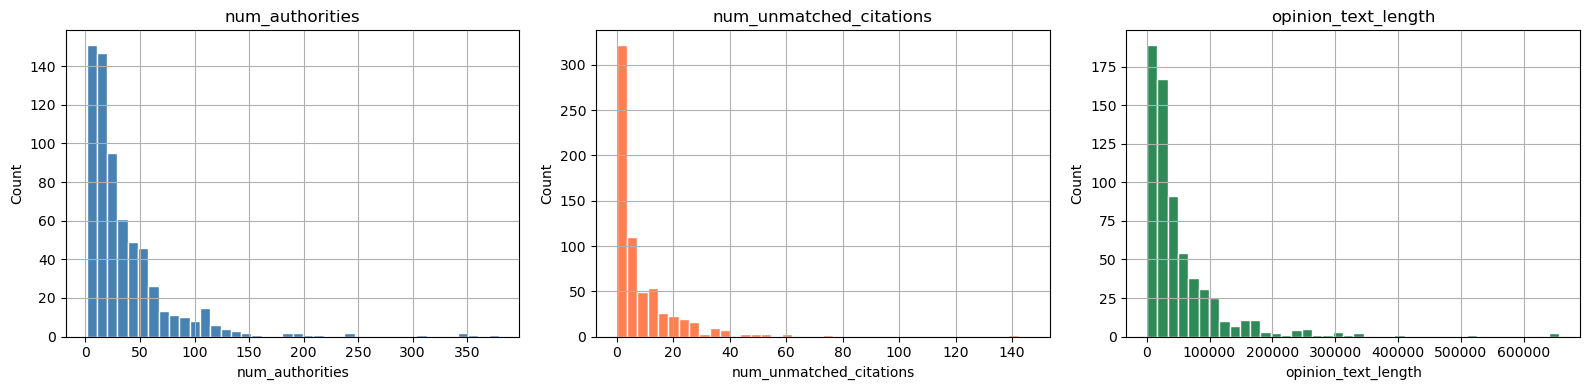

Percentiles for key columns:

num_authorities:
0.25     11.0
0.50     22.0
0.75     47.0
0.90     82.0
0.95    110.0
0.99    222.6

num_unmatched_citations:
0.25     1.0
0.50     4.0
0.75    11.0
0.90    23.0
0.95    34.0
0.99    77.6

opinion_text_length:
0.25     15268.0
0.50     29955.0
0.75     64818.0
0.90    114170.0
0.95    174681.0
0.99    316874.0


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, color in zip(axes, ["num_authorities", "num_unmatched_citations", "opinion_text_length"],
                            ["steelblue", "coral", "seagreen"]):
    citing[col].hist(bins=40, ax=ax, color=color, edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

print("Percentiles for key columns:")
for col in ["num_authorities", "num_unmatched_citations", "opinion_text_length"]:
    pcts = citing[col].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
    print(f"\n{col}:")
    print(pcts.to_string())

### Court × Source cross-tabulation

In [8]:
pd.crosstab(citing["court"], citing["source"], margins=True)

source,existing,sampled,All
court,,,
ca1,0,49,49
ca10,1,50,51
ca11,0,50,50
ca2,9,50,59
ca3,1,49,50
ca4,1,50,51
ca5,0,49,49
ca6,0,50,50
ca7,0,50,50


## 2. Cited Metadata Overview

In [9]:
cited.head()

,unique_id,citing_cluster_id,type,cited_cluster_id,cited_case_name,cited_case_citations
0,7163957-195707,7163957,authority,195707.0,United States v. Field,"1994 WL 594622, 1994 U.S. App. LEXIS 30689, 39..."
1,7163957-578246,7163957,authority,578246.0,United States v. Robert Owen Cox,"1992 WL 33949, 1992 U.S. App. LEXIS 2713, 957 ..."
2,7163957-658330,7163957,authority,658330.0,United States v. Leonard Lloyd (92-2106) Shawn...,"1993 U.S. App. LEXIS 28728, 10 F.3d 1197"
3,7163957-661494,7163957,authority,661494.0,United States v. Billy Joe Cochran,"1994 WL 16621, 1994 U.S. App. LEXIS 1194, 14 F..."
4,7163957-672076,7163957,authority,672076.0,United States v. Josephine Ledezma (92-6683) a...,26 F.3d 636


In [10]:
print(f"Unique citing cases in cited_metadata: {cited['citing_cluster_id'].nunique()}")
print(f"Unique cited cases: {cited['cited_cluster_id'].nunique()}")
print(f"\nType distribution:")
print(cited["type"].value_counts())

Unique citing cases in cited_metadata: 661
Unique cited cases: 16128

Type distribution:
type
authority    24311
unmatched     6240
Name: count, dtype: int64


### Citations per citing case

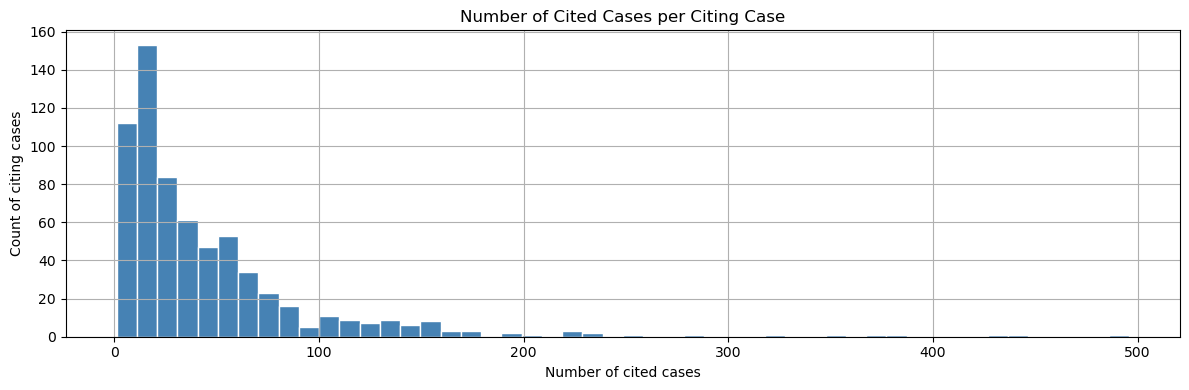

Mean: 46.2
Median: 28.0
Max: 496


In [11]:
cites_per_case = cited.groupby("citing_cluster_id").size()

fig, ax = plt.subplots(figsize=(12, 4))
cites_per_case.hist(bins=50, ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Number of Cited Cases per Citing Case")
ax.set_xlabel("Number of cited cases")
ax.set_ylabel("Count of citing cases")
plt.tight_layout()
plt.show()

print(f"Mean: {cites_per_case.mean():.1f}")
print(f"Median: {cites_per_case.median():.1f}")
print(f"Max: {cites_per_case.max()}")

## 3. Authority vs Non-Authority Citations

In [12]:
n_authority = len(authority)
n_cited_total = len(cited)
n_non_authority = n_cited_total - n_authority

print(f"Total cited entries:     {n_cited_total}")
print(f"Authority citations:     {n_authority} ({n_authority/n_cited_total*100:.1f}%)")
print(f"Non-authority citations: {n_non_authority} ({n_non_authority/n_cited_total*100:.1f}%)")

Total cited entries:     30551
Authority citations:     24311 (79.6%)
Non-authority citations: 6240 (20.4%)


## 4. Opinion Text Length by Court

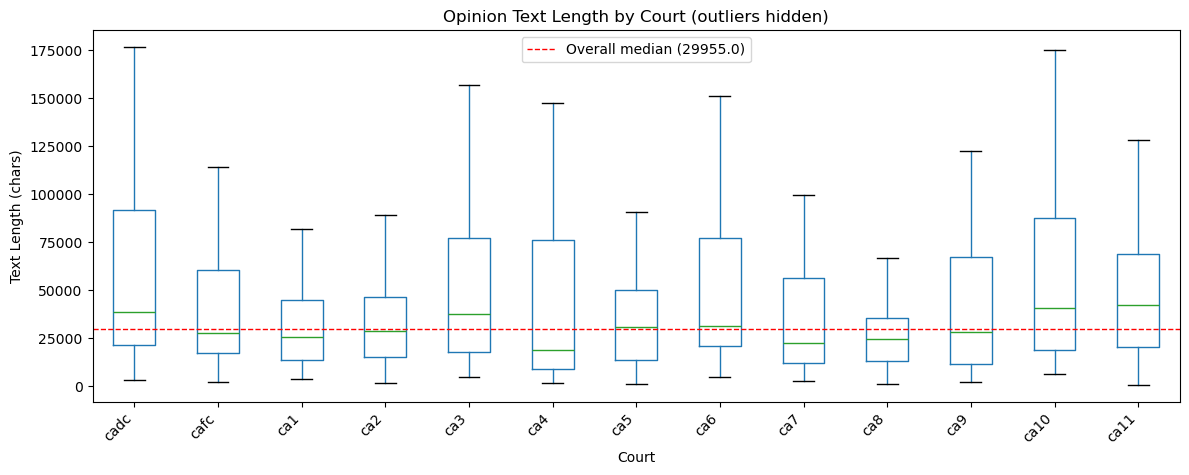


Median opinion text length by court:
court
cafc    42127.5
cadc    40494.0
ca1     38506.0
ca3     37411.0
ca6     31482.0
ca5     30796.0
ca2     28914.0
ca9     28111.5
ca10    27414.0
ca11    25647.5
ca8     24780.0
ca7     22228.0
ca4     18724.0
Name: opinion_text_length, dtype: float64


In [13]:
import re

def court_sort_key(name):
    # cadc/cafc first, then ca1-ca11 in numeric order, then everything else alphabetically
    if name in ("cadc", "cafc"):
        return (0, name)
    m = re.match(r"ca(\d+)$", name)
    if m:
        return (1, int(m.group(1)))
    return (2, name)

court_order = sorted(citing["court"].unique(), key=court_sort_key)

fig, ax = plt.subplots(figsize=(12, 5))
citing.boxplot(column="opinion_text_length", by="court", ax=ax,
               positions=range(len(court_order)),
               showfliers=False)
ax.set_xticklabels(court_order, rotation=45, ha="right")
ax.axhline(citing["opinion_text_length"].median(), color="red", linestyle="--", linewidth=1, label=f'Overall median ({citing["opinion_text_length"].median():.1f})')
ax.legend()
ax.set_title("Opinion Text Length by Court (outliers hidden)")
ax.set_xlabel("Court")
ax.set_ylabel("Text Length (chars)")
ax.grid(False)
fig.suptitle("")
plt.tight_layout()
plt.show()

print("\nMedian opinion text length by court:")
print(citing.groupby("court")["opinion_text_length"].median().sort_values(ascending=False))

## 5. Num Authorities by Court

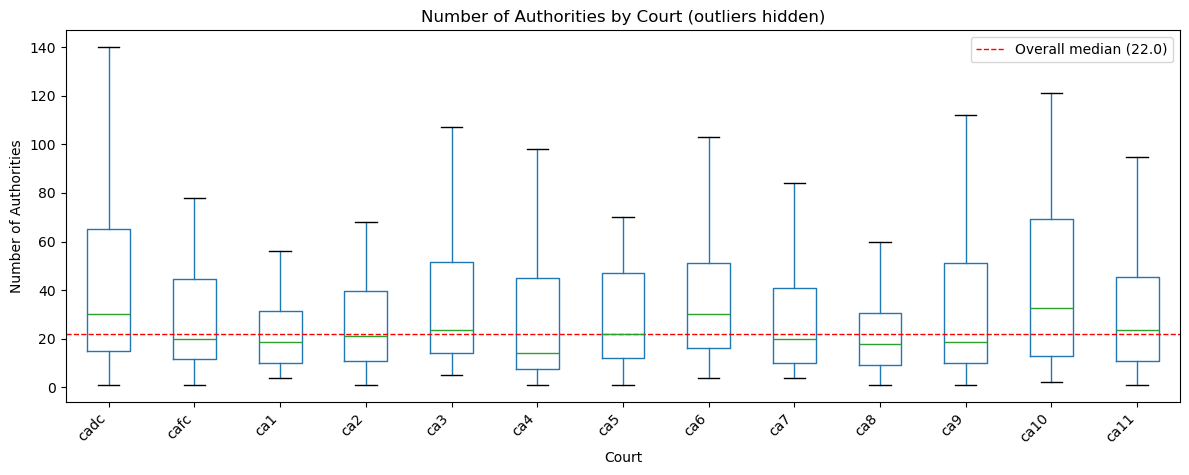


Median num_authorities by court:
court
cadc    32.5
ca1     30.0
ca6     30.0
ca3     23.5
cafc    23.5
ca5     22.0
ca2     21.0
ca10    20.0
ca7     20.0
ca11    18.5
ca9     18.5
ca8     18.0
ca4     14.0
Name: num_authorities, dtype: float64


In [14]:
fig, ax = plt.subplots(figsize=(12, 5))
citing.boxplot(column="num_authorities", by="court", ax=ax,
               positions=range(len(court_order)),
               showfliers=False)
ax.set_xticklabels(court_order, rotation=45, ha="right")
ax.axhline(citing["num_authorities"].median(), color="red", linestyle="--", linewidth=1, label=f'Overall median ({citing["num_authorities"].median():.1f})')
ax.legend()
ax.set_title("Number of Authorities by Court (outliers hidden)")
ax.set_xlabel("Court")
ax.set_ylabel("Number of Authorities")
ax.grid(False)
fig.suptitle("")
plt.tight_layout()
plt.show()

print("\nMedian num_authorities by court:")
print(citing.groupby("court")["num_authorities"].median().sort_values(ascending=False))

## 6. Relationship Between Text Length and Number of Citations

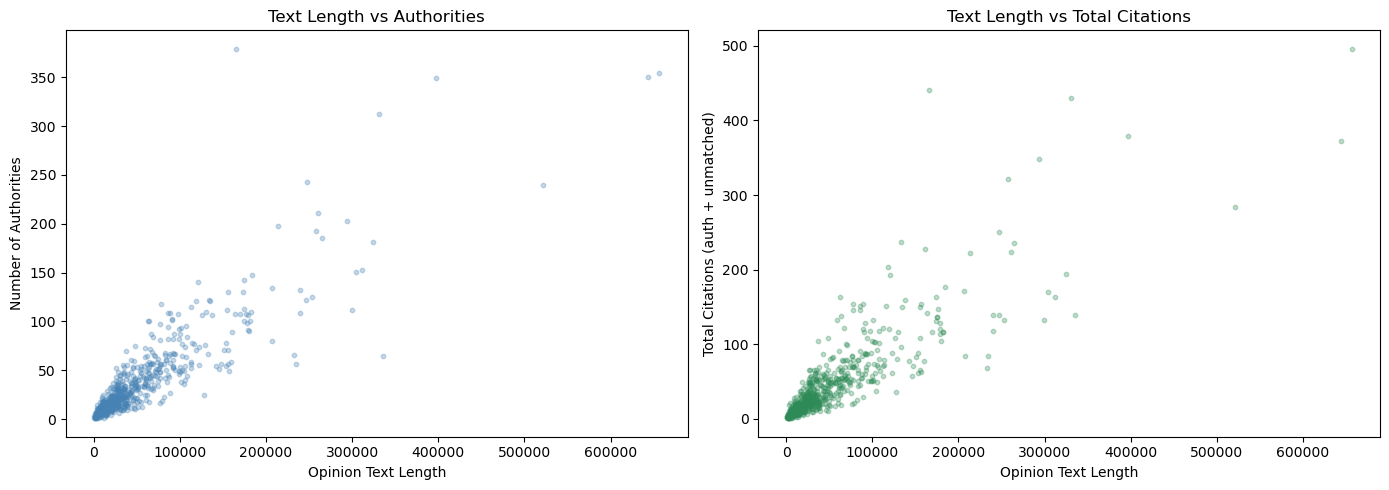

Correlation (text_length, num_authorities): 0.878
Correlation (text_length, total_citations): 0.858


In [15]:
citing["total_citations"] = citing["num_authorities"] + citing["num_unmatched_citations"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(citing["opinion_text_length"], citing["num_authorities"], alpha=0.3, s=10, color="steelblue")
axes[0].set_xlabel("Opinion Text Length")
axes[0].set_ylabel("Number of Authorities")
axes[0].set_title("Text Length vs Authorities")

axes[1].scatter(citing["opinion_text_length"], citing["total_citations"], alpha=0.3, s=10, color="seagreen")
axes[1].set_xlabel("Opinion Text Length")
axes[1].set_ylabel("Total Citations (auth + unmatched)")
axes[1].set_title("Text Length vs Total Citations")

plt.tight_layout()
plt.show()

print(f"Correlation (text_length, num_authorities): {citing['opinion_text_length'].corr(citing['num_authorities']):.3f}")
print(f"Correlation (text_length, total_citations): {citing['opinion_text_length'].corr(citing['total_citations']):.3f}")